# SafeSplit Walkthrough

This notebook is the explanatory layer for the SafeSplit midterm reproduction.

It imports the real project modules instead of re-implementing the system in notebook cells. The goal is to connect the paper's ideas to the codebase step by step:

- load CIFAR-10
- partition clients with the main-label non-IID split
- build the split model as `head -> backbone -> tail`
- inspect one clean split-learning step
- inspect one poisoned client step
- compute Main Task Accuracy (MA) and Backdoor Accuracy (BA)
- inspect SafeSplit checkpoint history
- visualize DCT and rotational scores
- show rollback selection
- run one small end-to-end example

The small runs here are intentionally lightweight so the notebook stays readable and interactive.

## Imports & Configs

In [1]:
# Automatically reload imported modules when source files change 
# Useful during notebook development to avoid restarting the kernel
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations

import random
from collections import Counter

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Subset

import config as cfg
import numpy as np
from data import (
    PixelTriggerAttack,
    PoisonedDataset,
    SemanticTriggerAttack,
    build_client_subsets,
    load_datasets,
    partition_data,
)

from defense import (
    SafeSplitDefense,
    dct_low_frequency, flatten_state_dict, rotational_signature, smallest_majority_sum
)

from evaluate import evaluate_backdoor, evaluate_model
from models import get_split_model
from training import SplitLearningTrainer
from utils.data import summarize_counter, unnormalize
from utils.display import result_to_row, show_rows
from utils.plot import plot_metric_summary

In [3]:
NOTEBOOK_SEED = 7
random.seed(NOTEBOOK_SEED)
np.random.seed(NOTEBOOK_SEED)
torch.manual_seed(NOTEBOOK_SEED)

device = cfg.resolve_device(None)
print(f"Notebook device: {device}")


Notebook device: cuda


## Load CIFAR-10

The project code uses the same dataset-loading path as the experiment runner. This cell downloads or reuses the cached CIFAR-10 dataset, prints the basic sizes, and shows a small sample grid.

Train size: 50000
Test size:  10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


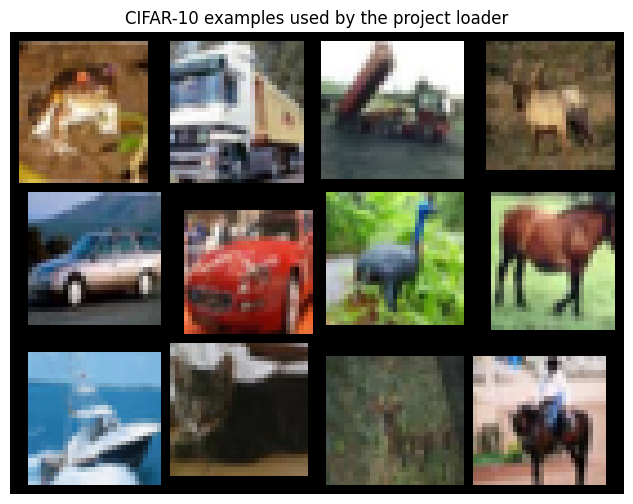

In [4]:
from utils.plot import plot_dataset_samples


train_dataset, test_dataset = load_datasets(cfg.DATA_DIR)
class_names = list(train_dataset.classes)

print(f"Train size: {len(train_dataset)}")
print(f"Test size:  {len(test_dataset)}")
print("Classes:", class_names)

plot_dataset_samples(
    dataset=train_dataset,    
    title="CIFAR-10 examples used by the project loader",
)

## Partition Clients With The Main-Label Non-IID Split

The paper and proposal focus on multiple clients with non-IID data. The implementation uses a simple main-label strategy: each client receives a dominant label plus an IID remainder controlled by the `iid_rate` parameter.

,client,samples,dominant_label,dominant_count,label_mix
0,0,128,truck,59,"{'airplane': 11, 'automobile': 11, 'bird': 6, 'cat': 4, 'deer': 5, 'dog': 11, 'frog': 8, 'horse': 4, 'ship': 9, 'truck': 59}"
1,1,128,airplane,60,"{'airplane': 60, 'automobile': 7, 'bird': 5, 'cat': 5, 'deer': 10, 'dog': 8, 'frog': 9, 'horse': 9, 'ship': 8, 'truck': 7}"
2,2,128,airplane,61,"{'airplane': 61, 'automobile': 9, 'bird': 4, 'cat': 8, 'deer': 5, 'dog': 8, 'frog': 10, 'horse': 8, 'ship': 6, 'truck': 9}"
3,3,128,truck,58,"{'airplane': 5, 'automobile': 4, 'bird': 7, 'cat': 9, 'deer': 13, 'dog': 5, 'frog': 9, 'horse': 11, 'ship': 7, 'truck': 58}"


<Showed 4 of 4 rows>


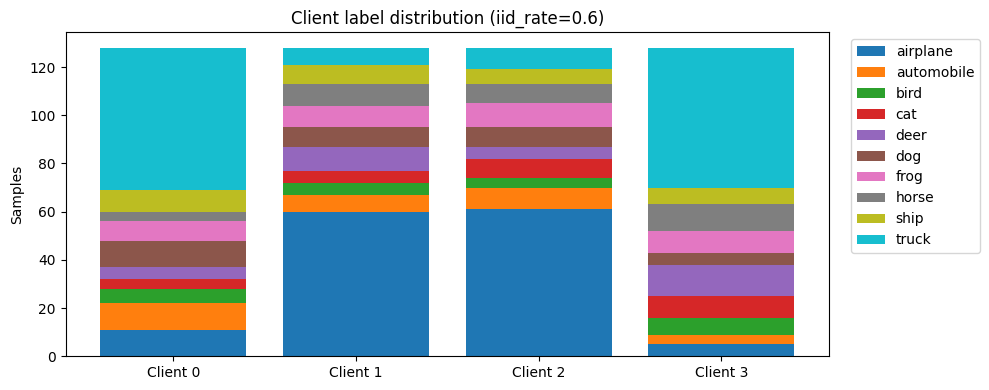

In [5]:
from utils.plot import plot_client_label_distribution

DEMO_NUM_CLIENTS = 4
DEMO_IID_RATE = 0.6
DEMO_MAX_SAMPLES_PER_CLIENT = 128

partitions = partition_data(
    train_dataset,
    num_clients=DEMO_NUM_CLIENTS,
    iid_rate=DEMO_IID_RATE,
    num_classes=cfg.NUM_CLASSES,
    seed=NOTEBOOK_SEED,
    max_samples_per_client=DEMO_MAX_SAMPLES_PER_CLIENT,
)
demo_client_subsets = build_client_subsets(train_dataset, partitions)

distribution_rows = []
distribution_matrix = []
for client_id, client_subset in enumerate(demo_client_subsets):
    labels = [int(train_dataset.targets[idx]) for idx in client_subset.indices]
    counts = Counter(labels)
    top_label, top_count = counts.most_common(1)[0]
    distribution_rows.append(
        {
            "client": client_id,
            "samples": len(client_subset),
            "dominant_label": class_names[top_label],
            "dominant_count": top_count,
            "label_mix": summarize_counter(counts, class_names),
        }
    )
    distribution_matrix.append([counts.get(label_idx, 0) for label_idx in range(cfg.NUM_CLASSES)])

show_rows(distribution_rows, max_rows=DEMO_NUM_CLIENTS)

plot_client_label_distribution(
    distribution_matrix,
    class_names,
    iid_rate=DEMO_IID_RATE,
)


## Build Head, Backbone, Tail

The project supports a split ResNet-18 and a smaller CNN. The notebook uses `simple_cnn` for fast inspection. This cell shows how one batch moves through the three pieces of the U-shaped split-learning model.

In [6]:
head, backbone, tail = get_split_model("simple_cnn", cfg.NUM_CLASSES)
head = head.to(device)
backbone = backbone.to(device)
tail = tail.to(device)

demo_loader = DataLoader(demo_client_subsets[0], batch_size=8, shuffle=False, num_workers=0)
demo_inputs, demo_targets = next(iter(demo_loader))
demo_inputs = demo_inputs.to(device)

with torch.no_grad():
    head_out = head(demo_inputs)
    backbone_out = backbone(head_out)
    logits = tail(backbone_out)

shape_rows = [
    {"stage": "input", "shape": tuple(demo_inputs.shape)},
    {"stage": "head output", "shape": tuple(head_out.shape)},
    {"stage": "backbone output", "shape": tuple(backbone_out.shape)},
    {"stage": "tail logits", "shape": tuple(logits.shape)},
]
show_rows(shape_rows)


,stage,shape
0,input,"(8, 3, 32, 32)"
1,head output,"(8, 32, 16, 16)"
2,backbone output,"(8, 128, 4, 4)"
3,tail logits,"(8, 10)"


<Showed 4 of 4 rows>


## Show One Clean Split-Learning Step And One Poisoned Client Step

This cell mirrors the split-gradient idea used in the trainer: the client computes the head activations, the server processes the backbone, the client finishes with the tail, and gradients cross the split boundary in reverse order.

It also shows what a poisoned sample looks like for the pixel trigger and how labels are reassigned by the attack.

,quantity,value
0,loss,2.1940865516662598
1,head grad norm,0.03710992634296417
2,backbone grad norm,0.022786753252148628


<Showed 3 of 3 rows>
Pixel attack relabels bird -> airplane
Semantic attack relabels automobile -> bird


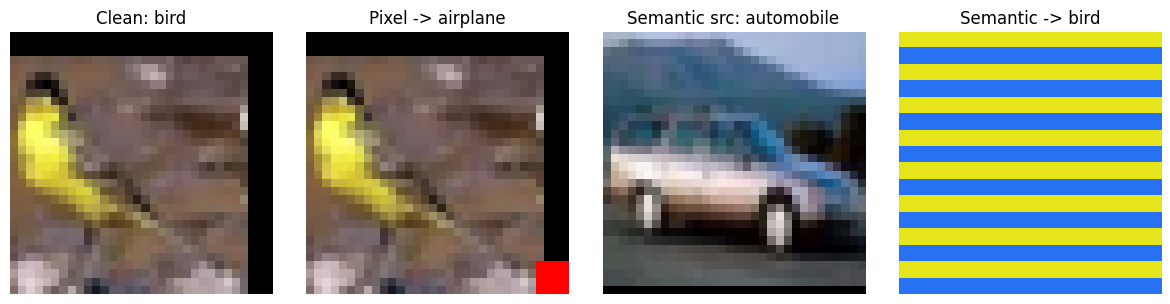

In [7]:
# ------------------------------------------------------------
# Build split-learning components
# ------------------------------------------------------------
step_head, step_backbone, step_tail = get_split_model(
    "simple_cnn",
    cfg.NUM_CLASSES
)

step_head = step_head.to(device)
step_backbone = step_backbone.to(device)
step_tail = step_tail.to(device)

# ------------------------------------------------------------
# Independent optimizers for each split segment
# ------------------------------------------------------------
head_opt = torch.optim.SGD(step_head.parameters(), lr=cfg.LR, momentum=cfg.MOMENTUM)
backbone_opt = torch.optim.SGD(step_backbone.parameters(), lr=cfg.LR, momentum=cfg.MOMENTUM)
tail_opt = torch.optim.SGD(step_tail.parameters(), lr=cfg.LR, momentum=cfg.MOMENTUM)

# ------------------------------------------------------------
# Load one client batch
# ------------------------------------------------------------
clean_loader = DataLoader(
    demo_client_subsets[0],
    batch_size=8,
    shuffle=True,
    num_workers=0,
)

clean_inputs, clean_targets = next(iter(clean_loader))

clean_inputs = clean_inputs.to(device)
clean_targets = clean_targets.to(device)


# ------------------------------------------------------------
# Reset gradients
# ------------------------------------------------------------
head_opt.zero_grad()
backbone_opt.zero_grad()
tail_opt.zero_grad()

# ------------------------------------------------------------
# Split-learning forward pass
#
#  - Client: input -> head#
#  - Server: smashed activations -> backbone#
#  - Client: backbone features -> tail -> logits
# ------------------------------------------------------------

# Client-side forward through head
smashed = step_head(clean_inputs)

# Simulate network boundary crossing. (The server receives detached activations)
smashed_detached = smashed.detach().requires_grad_(True)

# Server-side forward
backbone_output = step_backbone(smashed_detached)

# Simulate network boundary crossing. (The client receives detached activations)
backbone_output_detached = backbone_output.detach().requires_grad_(True)

# Client-side tail
logits = step_tail(backbone_output_detached)

# ------------------------------------------------------------
# Compute loss + Backward pass through the split boundaries
#
# Gradients propagate manually across: tail -> backbone -> head
# ------------------------------------------------------------
loss = torch.nn.functional.cross_entropy(logits, clean_targets)

# Tail backward and optimization step
loss.backward()
tail_opt.step()

# Send gradients across the split boundaries manually
backbone_output.backward(backbone_output_detached.grad)
backbone_opt.step()

# Send gradients back to head
smashed.backward(smashed_detached.grad)
head_opt.step()

# ------------------------------------------------------------
# Inspect gradient magnitudes
# ------------------------------------------------------------

clean_step_rows = [
    {
        "quantity": "loss",
        "value": float(loss.item()),
    },
    {
        "quantity": "head grad norm",
        "value": float(torch.norm(smashed_detached.grad).item()),
    },
    {
        "quantity": "backbone grad norm",
        "value": float(torch.norm(backbone_output_detached.grad).item()),
    },
]

show_rows(clean_step_rows)


# ============================================================
# Pixel Trigger Attack
# ============================================================
PIXEL_ATTACK = PixelTriggerAttack(
    trigger_size=cfg.TRIGGER_SIZE,
    position=cfg.TRIGGER_POS,
    target_label=cfg.PIXEL_TARGET_LABEL,
)

clean_image, clean_label = demo_client_subsets[0][0]

poisoned_image, poisoned_label = PIXEL_ATTACK.poison_sample(
    clean_image,
    int(clean_label),
)

print(f"Pixel attack relabels {class_names[int(clean_label)]} -> {class_names[int(poisoned_label)]}")

# ============================================================
# Semantic Trigger Attack
# ============================================================
SEMANTIC_ATTACK = SemanticTriggerAttack(
    source_label=cfg.SEMANTIC_SOURCE_LABEL,
    target_label=cfg.SEMANTIC_TARGET_LABEL,
)

# Find one sample from the semantic source class
semantic_index = next(
    i
    for i, label in enumerate(train_dataset.targets)
    if label == cfg.SEMANTIC_SOURCE_LABEL
)

clean_semantic_image, clean_semantic_label = train_dataset[semantic_index]

semantic_poisoned_image, semantic_poisoned_label = (
    SEMANTIC_ATTACK.poison_sample(
        clean_semantic_image,
        int(clean_semantic_label),
    )
)

print(f"Semantic attack relabels {class_names[int(clean_semantic_label)]} -> {class_names[int(semantic_poisoned_label)]}")

# ============================================================
# Visual comparison
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
visuals = [
    (clean_image, f"Clean: {class_names[int(clean_label)]}"),
    (poisoned_image, f"Pixel -> {class_names[int(poisoned_label)]}"),
    (clean_semantic_image, f"Semantic src: {class_names[int(clean_semantic_label)]}"),
    (semantic_poisoned_image, f"Semantic -> {class_names[int(semantic_poisoned_label)]}"),
]
for ax, (image, title) in zip(axes, visuals):
    ax.imshow(unnormalize(image).permute(1, 2, 0))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Compute BA And MA

The project keeps the evaluation separate from training. `MA` is the clean test accuracy, while `BA` is measured on a triggered test set where the attacker wants predictions to match the target label.

In [8]:
small_test = Subset(test_dataset, list(range(256)))
small_test_loader = DataLoader(small_test, batch_size=64, shuffle=False, num_workers=0)

# ------------------------------------------------------------
# Triggered test set used for Backdoor Accuracy (BA)
# ------------------------------------------------------------
small_trigger_set = PIXEL_ATTACK.build_backdoor_test_set(small_test)


# ------------------------------------------------------------
# Fresh untrained split model
# ------------------------------------------------------------
metric_head, metric_backbone, metric_tail = get_split_model("simple_cnn", cfg.NUM_CLASSES)

# ------------------------------------------------------------
# MA = main task accuracy (accuracy on the clean test set)
# BA = backdoor accuracy (accuracy on the triggered test set)
# ------------------------------------------------------------


initial_ma = evaluate_model(metric_head, metric_backbone, metric_tail, small_test_loader, device)
initial_ba = evaluate_backdoor(metric_head, metric_backbone, metric_tail, small_trigger_set, device)

show_rows([
    {"metric": "MA", "value": round(initial_ma, 4)},
    {"metric": "BA", "value": round(initial_ba, 4)},
])

,metric,value
0,MA,10.1562
1,BA,99.6094


<Showed 2 of 2 rows>


## Show SafeSplit Checkpoint History, DCT Score, Rotational Score, And Rollback Selection

SafeSplit analyzes the server-visible backbone after each client session. The implementation stores each checkpoint, computes a low-frequency DCT signature from the backbone update, computes a rotational signature from the current backbone state, scores both using the smallest-majority idea, and rolls back to the latest checkpoint that appears benign under both signals.

### What the DCT and Rotational Scores Mean

In this demo, each checkpoint (one client update) receives two anomaly scores:

- **DCT score (frequency-domain score):**  
  We apply a 2D **Discrete Cosine Transform (DCT)** to the backbone update and keep the low-frequency coefficients as a compact “pattern signature.” Then this signature is compared with the other checkpoints in the window.
 
  > A **low DCT score** means: “This update looks structurally similar to the majority.”
  
  > A **high DCT score** means: “This update has an unusual structural pattern.”

- **Rotational score (training-dynamics score):**  
  We compute another signature that captures how the backbone state is moving in parameter space, then compare it with the rest of the window.
  
  > A **low rotational score** means: “This update follows the same training dynamics as the majority.”

  > A **high rotational score** means: “This update evolves differently from the group.”

In simple terms:

- **Lower scores** → more normal relative to peers  
- **Higher scores** → more suspicious


SafeSplit keeps checkpoints that remain consistent with the majority under both scores in the current window, and selects the latest checkpoint that remains consistent with that benign majority.

Training history:


,round,clean_ma,backdoor_ba,selected_step,selected_client,trust_scores,defense_decisions
0,1,10.15625,100.0,4,3,None,[]


<Showed 1 of 1 rows>
Checkpoint history:


,step,round,client,rollback_selected
0,1,0,0,False
1,2,0,1,False
2,3,0,2,False
3,4,0,3,True


<Showed 4 of 4 rows>
Checkpoint scores and majorities:


,step,client,freq_score,rot_score,freq_majority,rot_majority,benign_intersection
0,1,0,1.116173,0.016655,False,False,False
1,2,1,0.691868,0.010975,True,True,True
2,3,2,0.691984,0.011091,True,True,True
3,4,3,0.964363,0.016235,True,True,True


<Showed 4 of 4 rows>
Selected rollback checkpoint: {'step': 4, 'client': 3, 'round': 0}


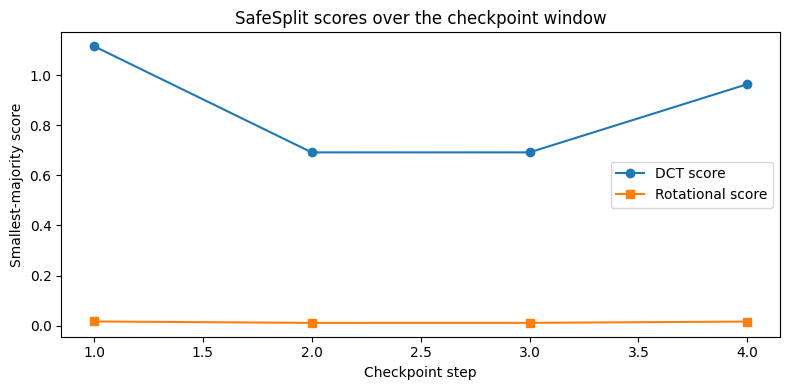

In [9]:
from training.trainer import RoundMetrics


tiny_test = Subset(test_dataset, list(range(256)))
tiny_test_loader = DataLoader(tiny_test, batch_size=64, shuffle=False, num_workers=0)
tiny_trigger_set = PIXEL_ATTACK.build_backdoor_test_set(tiny_test)

# Data Loaders
tiny_loaders = []

# Ids of the malicious clients in the demo
tiny_malicious_ids = {0}


for client_id, client_subset in enumerate(demo_client_subsets):
    clean_local_subset = Subset(train_dataset, client_subset.indices[:64])

    if client_id in tiny_malicious_ids:  # Inject poison into the local dataset of malicious clients
        poisoned_local_dataset = PoisonedDataset(
            clean_local_subset, PIXEL_ATTACK, poisoned_data_rate=0.5, seed=NOTEBOOK_SEED + client_id
        )
        local_dataloader = DataLoader(poisoned_local_dataset, batch_size=32, shuffle=True, num_workers=0)
    else:
        local_dataloader = DataLoader(clean_local_subset, batch_size=32, shuffle=True, num_workers=0)

    tiny_loaders.append(local_dataloader)

# ------------------------------------------------------------
# Build split-learning components for the demo
# ------------------------------------------------------------
tiny_head, tiny_backbone, tiny_tail = get_split_model("simple_cnn", cfg.NUM_CLASSES)

# ------------------------------------------------------------
# SafeSplit defense configuration
# ------------------------------------------------------------
tiny_defense = SafeSplitDefense(
    window_size=DEMO_NUM_CLIENTS,
    low_freq_frac=cfg.DCT_LOW_FREQ_FRAC,
    matrix_width=cfg.ROTATION_MATRIX_WIDTH
)

# ------------------------------------------------------------
# Initialize the Split Learning Trainer with the demo components
# ------------------------------------------------------------
tiny_trainer = SplitLearningTrainer(
    head_initial=tiny_head,
    backbone_initial=tiny_backbone,
    tail_initial=tiny_tail,
    client_loaders=tiny_loaders,
    device=device,
    lr=cfg.LR,
    momentum=cfg.MOMENTUM,
    weight_decay=cfg.WEIGHT_DECAY,
    local_epochs=1,
    defense=tiny_defense,
)

tiny_metrics_history: list[RoundMetrics] = tiny_trainer.run(num_rounds=1, test_loader=tiny_test_loader, trigger_set=tiny_trigger_set)
print("Training history:")

show_rows([round_metric.to_dict() for round_metric in tiny_metrics_history])


checkpoint_rows = []
for checkpoint in tiny_trainer.history:
    checkpoint_rows.append(
        {
            "step": checkpoint.step,
            "round": checkpoint.round_id,
            "client": checkpoint.client_id,
            "rollback_selected": checkpoint.step == tiny_trainer.last_selected_checkpoint.step,
        }
    )

print("Checkpoint history:")
show_rows(checkpoint_rows)


# ------------------------------------------------------------
# Compute DCT and rotational signatures
# ------------------------------------------------------------
checkpoint_window = tiny_trainer.history[-DEMO_NUM_CLIENTS:]

MAJORITY_SIZE = DEMO_NUM_CLIENTS // 2 + 1

freq_signatures = [
    dct_low_frequency(
        flatten_state_dict(checkpoint.update_state),
        cfg.ROTATION_MATRIX_WIDTH,
        cfg.DCT_LOW_FREQ_FRAC
    ) for checkpoint in checkpoint_window
]
rot_signatures = [
    rotational_signature(
        flatten_state_dict(checkpoint.backbone_state),
        cfg.ROTATION_MATRIX_WIDTH)
    for checkpoint in checkpoint_window
]

# ------------------------------------------------------------
# Compute anomaly scores
# ------------------------------------------------------------
frequency_scores, rotation_scores = [], []

for i in range(len(checkpoint_window)):

    freq_distances, rot_distances = [], []

    for j in range(len(checkpoint_window)):
        if i == j:
            continue
        freq_distances.append(
            torch.dist(freq_signatures[i], freq_signatures[j], p=2).item()
        )
        rot_distances.append(
            torch.mean(torch.abs(rot_signatures[i] - rot_signatures[j])).item()
        )

    # Smallest-majority aggregation used by SafeSplit
    frequency_scores.append(smallest_majority_sum(freq_distances, MAJORITY_SIZE))
    rotation_scores.append(smallest_majority_sum(rot_distances, MAJORITY_SIZE))


# ------------------------------------------------------------
# Majority-consistent checkpoints
# ------------------------------------------------------------
frequency_majority = set(
    sorted(
        range(len(checkpoint_window)),
        key=lambda idx: frequency_scores[idx],
    )[:MAJORITY_SIZE]
)

rotation_majority = set(
    sorted(
        range(len(checkpoint_window)),
        key=lambda idx: rotation_scores[idx],
    )[:MAJORITY_SIZE]
)

# Checkpoints considered benign by both signals
benign_indices = frequency_majority.intersection(
    rotation_majority
)


# ------------------------------------------------------------
# Display checkpoint scores
# ------------------------------------------------------------
score_rows = []
for idx, checkpoint in enumerate(checkpoint_window):
    score_rows.append(
        {
            "step": checkpoint.step,
            "client": checkpoint.client_id,
            "freq_score": round(frequency_scores[idx], 6),
            "rot_score": round(rotation_scores[idx], 6),
            "freq_majority": idx in frequency_majority,
            "rot_majority": idx in rotation_majority,
            "benign_intersection": idx in benign_indices,
        }
    )
print("Checkpoint scores and majorities:")
show_rows(score_rows)

# ------------------------------------------------------------
# Final rollback checkpoint selected by SafeSplit
# ------------------------------------------------------------
print(
    "Selected rollback checkpoint:",
    {
        "step": tiny_trainer.last_selected_checkpoint.step,
        "client": tiny_trainer.last_selected_checkpoint.client_id,
        "round": tiny_trainer.last_selected_checkpoint.round_id,
    },
)

# ------------------------------------------------------------
# Visualize SafeSplit scores
# ------------------------------------------------------------
steps = [checkpoint.step for checkpoint in checkpoint_window]
plt.figure(figsize=(8, 4))
plt.plot(steps, frequency_scores, marker="o", label="DCT score")
plt.plot(steps, rotation_scores, marker="s", label="Rotational score")
plt.xlabel("Checkpoint step")
plt.ylabel("Smallest-majority score")
plt.title("SafeSplit scores over the checkpoint window")
plt.legend()
plt.tight_layout()
plt.show()

## Run Real Experiments In The Notebook

The earlier sections are still the walkthrough layer. The cells below turn this notebook into the main experiment interface.

Use the shared preset system instead of editing tiny hard-coded values by hand:
- `lite`: fastest feedback
- `medium`: more informative but still notebook-friendly
- `paper`: paper-like midterm configuration

These cells call the same in-process runner used by the CLI, so notebook and script results now come from the same code path.

In [10]:
from config import Preset
from runner.experiment_runner import run_experiment
from utils.experiment_request import ExperimentRequest
from utils.experiment_result import ExperimentResult


NOTEBOOK_EXPERIMENT_PRESET = Preset.PAPER
NOTEBOOK_SAVE_JSON = False

preset_dict_rows: list[dict[str, object]] = []
for preset_name in (Preset.LITE, Preset.MEDIUM, Preset.PAPER):
    preset_cfg = cfg.resolve_preset(preset_name)
    preset_dict_rows.append(preset_cfg.to_dict())    

print("Experiment presets:")
show_rows(preset_dict_rows)


def notebook_request(**overrides) -> ExperimentRequest:
    request_values = {
        "preset": NOTEBOOK_EXPERIMENT_PRESET,
        "seed": NOTEBOOK_SEED,
        "device": device,
        "write_json": NOTEBOOK_SAVE_JSON,
    }
    request_values.update(overrides)
    return ExperimentRequest(**request_values)


def run_notebook_experiment(label: str, **overrides) -> tuple[ExperimentResult, dict[str, object]]:
    request = notebook_request(**overrides)
    result = run_experiment(request)
    row = {"label": label, **result_to_row(result)}
    return result, row


def summarize_history(result: ExperimentResult) -> list[dict[str, object]]:
    history_rows: list[dict[str, object]] = []
    for item in result.history:
        history_rows.append(
            {
                "round": item["round"],
                "clean_ma": round(float(item["clean_ma"]), 4),
                "backdoor_ba": round(float(item["backdoor_ba"]), 4),
                "selected_step": item["selected_step"],
                "selected_client": item["selected_client"],
            }
        )
    return history_rows


single_result, single_row = run_notebook_experiment(
    label="single-run-demo",
    defense="safesplit",
    backdoor="semantic",
)

print("Single experiment result:")
show_rows([single_row])

history_rows = summarize_history(single_result)

print("Experiment history summary:")
show_rows(history_rows)



Experiment presets:


,name,arch,num_clients,num_malicious,num_rounds,iid_rate,max_samples_per_client,local_epochs,batch_size,eval_batch_size
0,lite,simple_cnn,4,1,1,0.8,256.0,1,64,128
1,medium,resnet18,6,1,2,0.8,1024.0,1,96,128
2,paper,resnet18,10,2,5,0.8,nan,1,128,256


<Showed 3 of 3 rows>
Single experiment result:


,label,preset,arch,defense,backdoor,iid_rate,rounds,clients,malicious,final_MA,final_BA,results_path
0,single-run-demo,paper,resnet18,safesplit,semantic,0.8,5,10,2,39.5,0.0,None


<Showed 1 of 1 rows>
Experiment history summary:


,round,clean_ma,backdoor_ba,selected_step,selected_client
0,1,31.87,100.0,9,8
1,2,35.32,0.0,20,9
2,3,37.25,0.0,30,9
3,4,38.25,0.0,40,9
4,5,39.5,0.0,50,9


<Showed 5 of 5 rows>


## Midterm Comparison Suites

The next cell runs the same proposal-focused comparisons directly in the notebook:
- Table II subset: pixel and semantic, with and without SafeSplit
- Table III subset: semantic attack across IID rates `0.6`, `0.8`, `1.0`
- Reduced baseline panel at IID `0.6`

Set `NOTEBOOK_EXPERIMENT_PRESET` in the previous cell to `lite`, `medium`, or `paper` depending on how quickly you want results.

Prefilling formal experiment cache (20 experiments)...

Seed 42
[1/20] HIT  table-II-semantic-safesplit, seed=42
[2/20] HIT  table-III-iid-0.6-safesplit, seed=42
[3/20] HIT  table-III-iid-0.8-safesplit, seed=42
[4/20] HIT  table-III-iid-1.0-safesplit, seed=42

Seed 43
[5/20] HIT  table-II-semantic-safesplit, seed=43
[6/20] HIT  table-III-iid-0.6-safesplit, seed=43
[7/20] HIT  table-III-iid-0.8-safesplit, seed=43
[8/20] HIT  table-III-iid-1.0-safesplit, seed=43

Seed 44
[9/20] HIT  table-II-semantic-safesplit, seed=44
[10/20] HIT  table-III-iid-0.6-safesplit, seed=44
[11/20] HIT  table-III-iid-0.8-safesplit, seed=44
[12/20] HIT  table-III-iid-1.0-safesplit, seed=44

Seed 45
[13/20] HIT  table-II-semantic-safesplit, seed=45
[14/20] HIT  table-III-iid-0.6-safesplit, seed=45
[15/20] HIT  table-III-iid-0.8-safesplit, seed=45
[16/20] HIT  table-III-iid-1.0-safesplit, seed=45

Seed 46
[17/20] HIT  table-II-semantic-safesplit, seed=46
[18/20] HIT  table-III-iid-0.6-safesplit, seed=46
[19/20] H

,seed,max_safesplit_BA,passed
0,42,0.0,True


<Showed 1 of 1 rows>
Selected reporting seed: 42
Table II subset (paper preset, seed 42)


,label,preset,arch,defense,backdoor,iid_rate,rounds,clients,malicious,final_MA,final_BA,results_path
0,table-II-semantic-none,paper,resnet18,none,semantic,0.8,5,10,2,52.13,100.0,None
1,table-II-semantic-safesplit,paper,resnet18,safesplit,semantic,0.8,5,10,2,46.99,0.0,None
2,table-II-pixel-none,paper,resnet18,none,pixel,0.8,5,10,2,52.37,99.97,None
3,table-II-pixel-safesplit,paper,resnet18,safesplit,pixel,0.8,5,10,2,45.61,7.1,None


<Showed 4 of 4 rows>


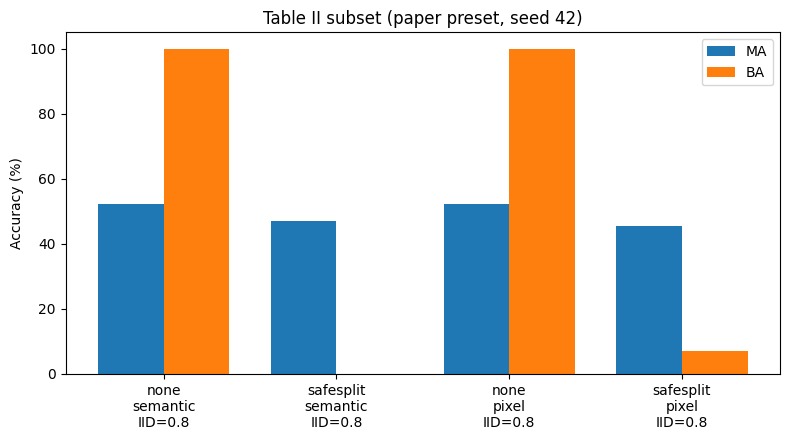

Cache stats: {'hits': 24, 'misses': 0, 'recomputed': 0, 'corrupt_recovered': 0}
Table III subset (paper preset, seed 42)


,label,preset,arch,defense,backdoor,iid_rate,rounds,clients,malicious,final_MA,final_BA,results_path
0,table-III-iid-0.6-none,paper,resnet18,none,semantic,0.6,5,10,2,50.34,100.0,None
1,table-III-iid-0.6-safesplit,paper,resnet18,safesplit,semantic,0.6,5,10,2,42.01,0.0,None
2,table-III-iid-0.8-none,paper,resnet18,none,semantic,0.8,5,10,2,53.1,100.0,None
3,table-III-iid-0.8-safesplit,paper,resnet18,safesplit,semantic,0.8,5,10,2,42.51,0.0,None
4,table-III-iid-1.0-none,paper,resnet18,none,semantic,1.0,5,10,2,56.35,100.0,None
5,table-III-iid-1.0-safesplit,paper,resnet18,safesplit,semantic,1.0,5,10,2,47.46,0.0,None


<Showed 6 of 6 rows>


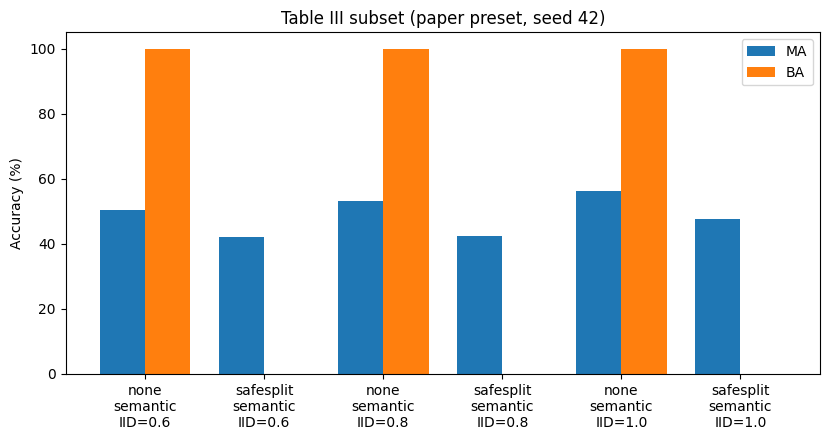

Cache stats: {'hits': 27, 'misses': 3, 'recomputed': 3, 'corrupt_recovered': 0}
Reduced baseline panel (paper preset, seed 42)


,label,preset,arch,defense,backdoor,iid_rate,rounds,clients,malicious,final_MA,final_BA,results_path
0,baseline-iid-0.6-none,paper,resnet18,none,semantic,0.6,5,10,2,50.34,100.0,None
1,baseline-iid-0.6-dp,paper,resnet18,dp,semantic,0.6,5,10,2,10.0,0.0,None
2,baseline-iid-0.6-krum,paper,resnet18,krum,semantic,0.6,5,10,2,36.46,0.0,None
3,baseline-iid-0.6-safesplit,paper,resnet18,safesplit,semantic,0.6,5,10,2,42.01,0.0,None


<Showed 4 of 4 rows>


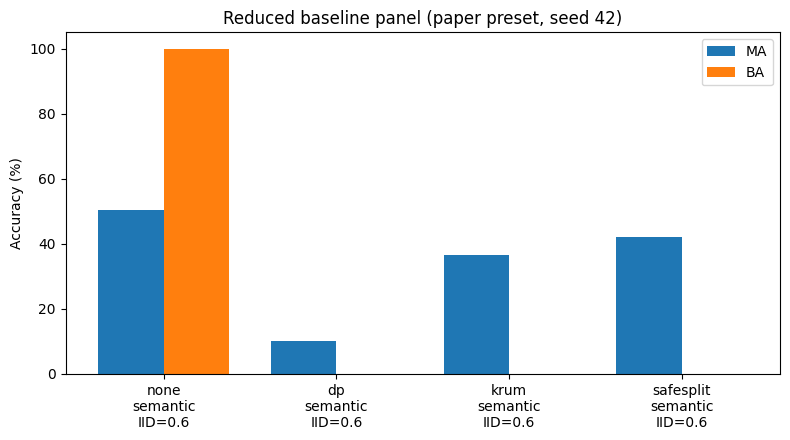

Cache stats: {'hits': 29, 'misses': 5, 'recomputed': 5, 'corrupt_recovered': 0}


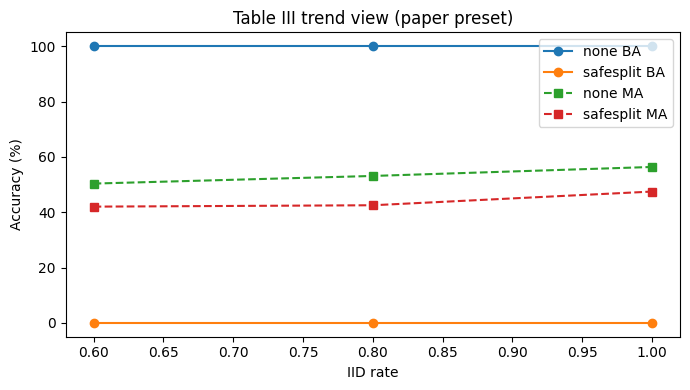

,label,takeaway,MA,BA
0,table-II-semantic-none,No defense is expected to allow higher BA,52.13,100.0
1,table-II-semantic-safesplit,SafeSplit suppresses BA,46.99,0.0
2,table-II-pixel-none,No defense is expected to allow higher BA,52.37,99.97
3,table-II-pixel-safesplit,SafeSplit suppresses BA,45.61,7.1


<Showed 4 of 4 rows>


In [12]:
from config import Preset


from utils.formal_comparison_cache import (
    FormalCase,
    FormalExperimentCache,
    run_case_group,
    select_reporting_seed,
)
NOTEBOOK_EXPERIMENT_PRESET = Preset.PAPER
NOTEBOOK_SAVE_JSON = False
# ------------------------------------------------------------------
# Table II reproduction subset
#
# Compare:
#   - semantic vs pixel backdoors
#   - no defense vs SafeSplit
# ------------------------------------------------------------------

TABLE_II_CASES = [
    FormalCase("table-II-semantic-none", {"backdoor": "semantic", "defense": "none"}),
    FormalCase("table-II-semantic-safesplit", {"backdoor": "semantic", "defense": "safesplit"}),
    FormalCase("table-II-pixel-none", {"backdoor": "pixel", "defense": "none"}),
    FormalCase("table-II-pixel-safesplit", {"backdoor": "pixel", "defense": "safesplit"}),
]

# ------------------------------------------------------------------
# Table III reproduction subset
#
# Evaluate robustness under different IID rates.
# Only semantic attacks are used here.
# ------------------------------------------------------------------
TABLE_III_CASES = [
    FormalCase(f"table-III-iid-{iid}-{defense}", {"backdoor": "semantic", "defense": defense, "iid_rate": iid})
    for iid in (0.6, 0.8, 1.0)
    for defense in ("none", "safesplit")
]

# ------------------------------------------------------------------
# Reduced baseline comparison panel
#
# Compare SafeSplit against:
#   - no defense
#   - differential privacy
#   - KRUM
# ------------------------------------------------------------------
BASELINE_CASES = [
    FormalCase(f"baseline-iid-0.6-{defense}", {"backdoor": "semantic", "defense": defense, "iid_rate": 0.6})
    for defense in ("none", "dp", "krum", "safesplit")
]

# ------------------------------------------------------------------
# Candidate seeds used to select a stable reporting seed.
#
# The selected seed should produce low BA for SafeSplit
# across the key reporting experiments.
# ------------------------------------------------------------------
REPORTING_SEED_CANDIDATES = (42, 43, 44, 45, 46)
REPORTING_SEED_BA_LIMIT = 10.0


# --------------------------------------------------------------
# Key SafeSplit experiments used for reporting-seed validation.
#
# The goal is to avoid presenting a seed where SafeSplit behaves abnormally badly due to stochastic variation.
# --------------------------------------------------------------
def reporting_seed_cases() -> list[FormalCase]:
    return [
        FormalCase("table-II-semantic-safesplit", {"backdoor": "semantic", "defense": "safesplit"}),
        FormalCase(
            "table-III-iid-0.6-safesplit",
            {"backdoor": "semantic", "defense": "safesplit", "iid_rate": 0.6},
        ),
        FormalCase(
            "table-III-iid-0.8-safesplit",
            {"backdoor": "semantic", "defense": "safesplit", "iid_rate": 0.8},
        ),
        FormalCase(
            "table-III-iid-1.0-safesplit",
            {"backdoor": "semantic", "defense": "safesplit", "iid_rate": 1.0},
        ),
    ]


# ------------------------------------------------------------------
# Persistent experiment cache
#
# Avoid recomputing expensive notebook experiments across reruns.
# ------------------------------------------------------------------
formal_cache = FormalExperimentCache(
    cache_dir=cfg.DATA_DIR / "formal_experiment_cache",
    preset=NOTEBOOK_EXPERIMENT_PRESET,
    schema_version="v1",
    device=device,
    write_json=NOTEBOOK_SAVE_JSON,
)

# ------------------------------------------------------------------
# Optional full prefill for all candidate seeds.
# Uncomment to pre-run all reporting seed candidates for the key reporting experiments.
# ------------------------------------------------------------------
formal_cache.prefill(reporting_seed_cases(), REPORTING_SEED_CANDIDATES)

# ------------------------------------------------------------------
# Automatically select a stable reporting seed.
#
# The selected seed should keep SafeSplit BA below the configured
# threshold across the key reporting cases.
# ------------------------------------------------------------------
REPORTING_SEED = select_reporting_seed(
    cache=formal_cache,
    reporting_cases=reporting_seed_cases(),
    seed_candidates=REPORTING_SEED_CANDIDATES,
    ba_limit=REPORTING_SEED_BA_LIMIT,
    default_seed=NOTEBOOK_SEED,
)
print(f"Selected reporting seed: {REPORTING_SEED}")

# ------------------------------------------------------------------
# Execute formal comparison suites
# ------------------------------------------------------------------
table_ii_rows = run_case_group(
    cache=formal_cache,
    cases=TABLE_II_CASES,
    title=f"Table II subset ({NOTEBOOK_EXPERIMENT_PRESET} preset, seed {REPORTING_SEED})",
    seed=REPORTING_SEED,
)
table_iii_rows = run_case_group(
    cache=formal_cache,
    cases=TABLE_III_CASES,
    title=f"Table III subset ({NOTEBOOK_EXPERIMENT_PRESET} preset, seed {REPORTING_SEED})",
    seed=REPORTING_SEED,
)
baseline_rows = run_case_group(
    cache=formal_cache,
    cases=BASELINE_CASES,
    title=f"Reduced baseline panel ({NOTEBOOK_EXPERIMENT_PRESET} preset, seed {REPORTING_SEED})",
    seed=REPORTING_SEED,
)


# ------------------------------------------------------------------
# Visualize Table III trends
#
# Compare:
#   - no defense
#   - SafeSplit
#
# across IID rates for both:
#   - BA (backdoor accuracy)
#   - MA (main task accuracy)
# ------------------------------------------------------------------
safe_rows = [row for row in table_iii_rows if row["defense"] == "safesplit"]
none_rows = [row for row in table_iii_rows if row["defense"] == "none"]

safe_rows = sorted(safe_rows, key=lambda row: row["iid_rate"])
none_rows = sorted(none_rows, key=lambda row: row["iid_rate"])

plt.figure(figsize=(7, 4))
plt.plot([row["iid_rate"] for row in none_rows], [row["final_BA"] for row in none_rows], marker="o", label="none BA")
plt.plot([row["iid_rate"] for row in safe_rows], [row["final_BA"]
         for row in safe_rows], marker="o", label="safesplit BA")
plt.plot([row["iid_rate"] for row in none_rows], [row["final_MA"]
         for row in none_rows], marker="s", linestyle="--", label="none MA")
plt.plot([row["iid_rate"] for row in safe_rows], [row["final_MA"]
         for row in safe_rows], marker="s", linestyle="--", label="safesplit MA")
plt.xlabel("IID rate")
plt.ylabel("Accuracy (%)")
plt.title(f"Table III trend view ({NOTEBOOK_EXPERIMENT_PRESET} preset)")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Qualitative interpretation table
# ------------------------------------------------------------------
interpretation_rows = []
for row in table_ii_rows:
    interpretation_rows.append(
        {
            "label": row["label"],

            "takeaway":
                "SafeSplit suppresses BA"
                if row["defense"] == "safesplit"
                else "No defense is expected to allow higher BA",

            "MA": row["final_MA"],            
            "BA": row["final_BA"],
        }
    )
show_rows(interpretation_rows, max_rows=len(interpretation_rows))

## Run One Small End-To-End Example

The final cell compares a tiny no-defense run against a tiny SafeSplit run. These numbers are not meant to exactly match the paper. They are a compact sanity check that the code path is wired correctly and that the qualitative direction of the defense can be inspected in one notebook session.

defense   | final_MA | final_BA | selected_step
----------+----------+----------+--------------
none      | 10.1562  | 0.0      | 4            
safesplit | 11.7188  | 10.9375  | 4            


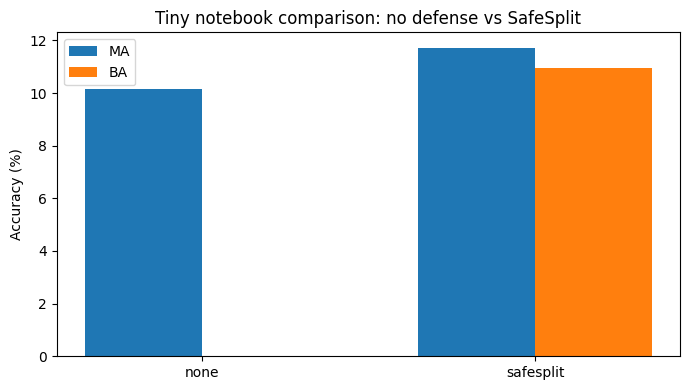

In [ ]:
def build_tiny_client_loaders(attack=None):
    loaders = []
    malicious_ids = {0} if attack is not None else set()
    for client_id, subset in enumerate(demo_client_subsets):
        local_subset = Subset(train_dataset, subset.indices[:64])
        local_dataset = local_subset
        if client_id in malicious_ids and attack is not None:
            local_dataset = PoisonedDataset(local_subset, attack, poisoned_data_rate=0.5,
                                            seed=NOTEBOOK_SEED + 100 + client_id)
        loaders.append(DataLoader(local_dataset, batch_size=32, shuffle=True, num_workers=0))
    return loaders


def run_tiny_experiment(defense_name: str):
    attack = PixelTriggerAttack(
        trigger_size=cfg.TRIGGER_SIZE,
        position=cfg.TRIGGER_POS,
        target_label=cfg.PIXEL_TARGET_LABEL
    )

    loaders = build_tiny_client_loaders(attack=attack)

    head0, backbone0, tail0 = get_split_model("simple_cnn", cfg.NUM_CLASSES)
    defense = None

    if defense_name == "safesplit":
        defense = SafeSplitDefense(
            window_size=DEMO_NUM_CLIENTS,
            low_freq_frac=cfg.DCT_LOW_FREQ_FRAC,
            matrix_width=cfg.ROTATION_MATRIX_WIDTH,
        )

    trainer = SplitLearningTrainer(
        head_initial=head0,
        backbone_initial=backbone0,
        tail_initial=tail0,
        client_loaders=loaders,
        device=device,
        lr=cfg.LR,
        momentum=cfg.MOMENTUM,
        weight_decay=cfg.WEIGHT_DECAY,
        local_epochs=1,
        defense=defense,
    )

    trigger_set = attack.build_backdoor_test_set(tiny_test)    

    history: list[RoundMetrics] = trainer.run(num_rounds=1, test_loader=tiny_test_loader, trigger_set=trigger_set)
    
    return {
        "defense": defense_name,
        "final_MA": round(history[-1].clean_ma, 4),
        "final_BA": round(history[-1].backdoor_ba, 4),
        "selected_step": history[-1].selected_step,
    }


comparison_rows = [run_tiny_experiment("none"), run_tiny_experiment("safesplit")]
show_rows(comparison_rows)

labels = [row["defense"] for row in comparison_rows]
ma_values = [row["final_MA"] for row in comparison_rows]
ba_values = [row["final_BA"] for row in comparison_rows]
x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(7, 4))
plt.bar(x - width / 2, ma_values, width, label="MA")
plt.bar(x + width / 2, ba_values, width, label="BA")
plt.xticks(x, labels)
plt.ylabel("Accuracy (%)")
plt.title("Tiny notebook comparison: no defense vs SafeSplit")
plt.legend()
plt.tight_layout()
plt.show()

## Extension: Temporal Trust Score

The reproduction above evaluates SafeSplit as a checkpoint-level defense. The extension adds a temporal trust score that tracks each client across rounds. This keeps the original reproduction results unchanged and adds a separate experiment for slowly poisoning clients.

Motivation: SafeSplit can reject suspicious checkpoints in the current window, while the trust score captures repeated mild suspicious behavior from the same client over time. This is useful for a malicious client that increases poisoning gradually instead of launching a strong attack immediately.

Fixed client assumption: the reported extension keeps the client set fixed during training. Clients do not join or leave between rounds.

Trust rule used in this notebook:

```text
suspiciousness = mean(percentile_rank(DCT score), percentile_rank(rotational score))

if suspiciousness < soft_threshold and the update is in the SafeSplit benign set:
    trust = min(1.0, trust + reward)
else:
    trust = max(0.0, trust - penalty * suspiciousness)

client is low trust if trust <= trust_threshold
```

The default parameters are `reward = 0.02`, `penalty = 0.10`, `soft_threshold = 0.60`, and `trust_threshold = 0.70`. This threshold is strict enough to flag repeated suspicious behavior in the slow poisoning setting, while still showing the MA and BA tradeoff.

In [ ]:
# Paper-aligned display tables for easier side-by-side comparison with the paper.
from pathlib import Path

NOTEBOOK_EXPORT_README_ASSETS = False
README_ASSET_DIR = Path("assets/readme")


def paper_round(value):
    if value is None:
        return "-"
    return round(float(value), 2)


def save_table_svg(rows: list[dict], filename: str, title: str) -> None:
    if not NOTEBOOK_EXPORT_README_ASSETS or not rows:
        return
    README_ASSET_DIR.mkdir(parents=True, exist_ok=True)
    headers = list(rows[0].keys())
    cell_text = [[row.get(header, "") for header in headers] for row in rows]
    fig_height = max(1.4, 0.45 * (len(rows) + 1))
    fig, ax = plt.subplots(figsize=(max(7, len(headers) * 1.35), fig_height))
    ax.axis("off")
    ax.set_title(title, pad=12)
    table = ax.table(cellText=cell_text, colLabels=headers, loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.2)
    fig.tight_layout()
    fig.savefig(README_ASSET_DIR / filename, bbox_inches="tight")
    plt.close(fig)


def format_table_ii(rows: list[dict]) -> list[dict]:
    ordered = sorted(rows, key=lambda row: (row["backdoor"], row["defense"] != "none"))
    return [
        {
            "Attack": row["backdoor"],
            "Defense": row["defense"],
            "IID Rate": row["iid_rate"],
            "MA (%)": paper_round(row["final_MA"]),
            "BA (%)": paper_round(row["final_BA"]),
        }
        for row in ordered
    ]


def format_table_iii(rows: list[dict]) -> list[dict]:
    by_iid = {}
    for row in rows:
        by_iid.setdefault(row["iid_rate"], {})[row["defense"]] = row
    formatted = []
    for iid_rate in sorted(by_iid):
        none_row = by_iid[iid_rate].get("none", {})
        safe_row = by_iid[iid_rate].get("safesplit", {})
        formatted.append(
            {
                "IID Rate": iid_rate,
                "None MA (%)": paper_round(none_row.get("final_MA")),
                "None BA (%)": paper_round(none_row.get("final_BA")),
                "SafeSplit MA (%)": paper_round(safe_row.get("final_MA")),
                "SafeSplit BA (%)": paper_round(safe_row.get("final_BA")),
            }
        )
    return formatted


def format_baseline_panel(rows: list[dict]) -> list[dict]:
    order = {"none": 0, "dp": 1, "krum": 2, "safesplit": 3}
    ordered = sorted(rows, key=lambda row: order.get(row["defense"], 99))
    return [
        {
            "Baseline": row["defense"],
            "Attack": row["backdoor"],
            "IID Rate": row["iid_rate"],
            "MA (%)": paper_round(row["final_MA"]),
            "BA (%)": paper_round(row["final_BA"]),
        }
        for row in ordered
    ]


if "table_ii_rows" in globals():
    paper_table_ii = format_table_ii(table_ii_rows)
    print("Paper-aligned Table II view")
    show_rows(paper_table_ii, max_rows=len(paper_table_ii))
    save_table_svg(paper_table_ii, "paper-aligned-table-ii.svg", "Paper-aligned Table II view")

if "table_iii_rows" in globals():
    paper_table_iii = format_table_iii(table_iii_rows)
    print("\nPaper-aligned Table III view")
    show_rows(paper_table_iii, max_rows=len(paper_table_iii))
    save_table_svg(paper_table_iii, "paper-aligned-table-iii.svg", "Paper-aligned Table III view")

if "baseline_rows" in globals():
    paper_baseline_panel = format_baseline_panel(baseline_rows)
    print("\nPaper-aligned baseline view")
    show_rows(paper_baseline_panel, max_rows=len(paper_baseline_panel))
    save_table_svg(paper_baseline_panel, "paper-aligned-baseline-panel.svg", "Paper-aligned baseline view")


def check_reproduction_rows(table_ii_rows: list[dict], table_iii_rows: list[dict]) -> list[dict]:
    checks = []
    table_ii_semantic_safe = next(
        (row for row in table_ii_rows if row["backdoor"] == "semantic" and row["defense"] == "safesplit"),
        None,
    )
    if table_ii_semantic_safe is not None:
        checks.append(
            {
                "check": "Table II semantic SafeSplit BA",
                "value": paper_round(table_ii_semantic_safe["final_BA"]),
                "status": "pass" if table_ii_semantic_safe["final_BA"] <= 20 else "rerun",
            }
        )

    for iid_rate in (0.8, 1.0):
        row = next(
            (
                row
                for row in table_iii_rows
                if row["iid_rate"] == iid_rate and row["defense"] == "safesplit"
            ),
            None,
        )
        if row is not None:
            checks.append(
                {
                    "check": f"Table III IID {iid_rate} SafeSplit BA",
                    "value": paper_round(row["final_BA"]),
                    "status": "pass" if row["final_BA"] <= 20 else "rerun",
                }
            )
    return checks


if "table_ii_rows" in globals() and "table_iii_rows" in globals():
    sanity_rows = check_reproduction_rows(table_ii_rows, table_iii_rows)
    print("\nReproduction sanity check")
    show_rows(sanity_rows, max_rows=len(sanity_rows))

Paper-aligned Table II view


,Attack,Defense,IID Rate,MA (%),BA (%)
0,pixel,none,0.8,52.37,99.97
1,pixel,safesplit,0.8,45.61,7.1
2,semantic,none,0.8,52.13,100.0
3,semantic,safesplit,0.8,46.99,0.0


<Showed 4 of 4 rows>

Paper-aligned Table III view


,IID Rate,None MA (%),None BA (%),SafeSplit MA (%),SafeSplit BA (%)
0,0.6,50.34,100.0,42.01,0.0
1,0.8,53.1,100.0,42.51,0.0
2,1.0,56.35,100.0,47.46,0.0


<Showed 3 of 3 rows>

Paper-aligned baseline view


,Baseline,Attack,IID Rate,MA (%),BA (%)
0,none,semantic,0.6,50.34,100.0
1,dp,semantic,0.6,10.0,0.0
2,krum,semantic,0.6,36.46,0.0
3,safesplit,semantic,0.6,42.01,0.0


<Showed 4 of 4 rows>

Reproduction sanity check


,check,value,status
0,Table II semantic SafeSplit BA,0.0,pass
1,Table III IID 0.8 SafeSplit BA,0.0,pass
2,Table III IID 1.0 SafeSplit BA,0.0,pass


<Showed 3 of 3 rows>


In [21]:
if "REPORTING_SEED" in globals():
    print(f"Formal comparison tables used reporting seed {REPORTING_SEED}.")

if "sanity_rows" in globals():
    show_rows(sanity_rows, max_rows=len(sanity_rows))

Formal comparison tables used reporting seed 42.


,check,value,status
0,Table II semantic SafeSplit BA,0.0,pass
1,Table III IID 0.8 SafeSplit BA,0.0,pass
2,Table III IID 1.0 SafeSplit BA,0.0,pass


<Showed 3 of 3 rows>


Temporal Trust extension summary


,Label,Defense,Attack,IID Rate,MA (%),BA (%),Final Mal Trust,Final Benign Trust,Low Trust Flags
0,slow-none,none,slow semantic,0.8,53.22,100.0,-,-,0
1,slow-safesplit,safesplit,slow semantic,0.8,45.12,0.0,-,-,0
2,slow-safesplit-trust,safesplit_trust,slow semantic,0.8,45.87,0.0,0.65,0.85,2


<Showed 3 of 3 rows>


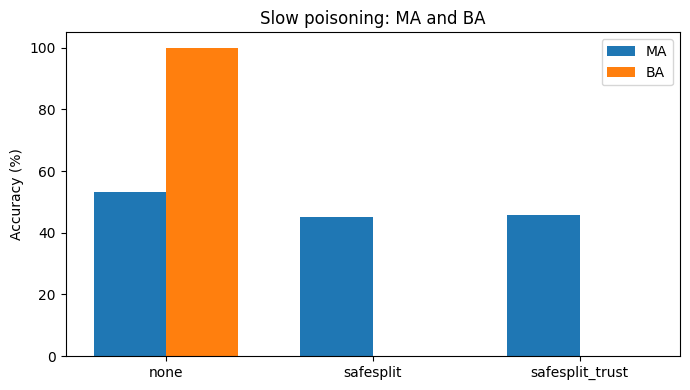

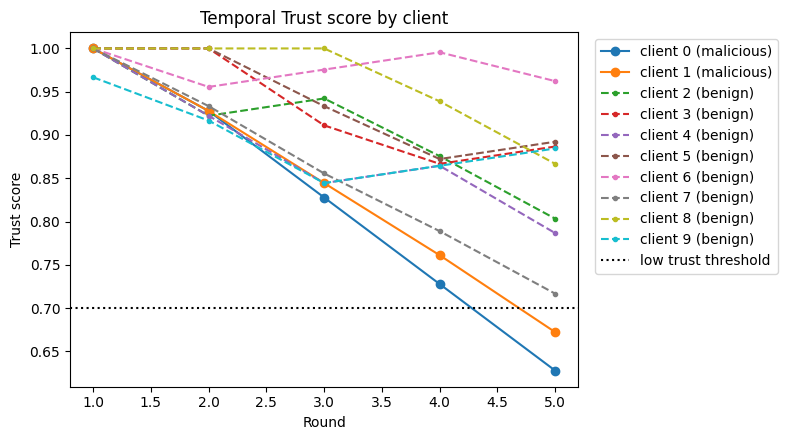

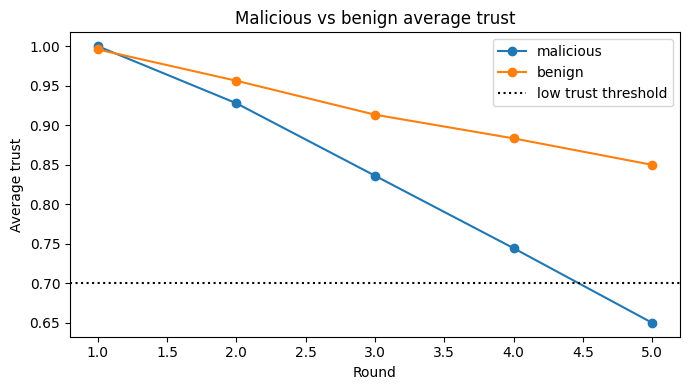


Latest trust decisions


,Step,Client,Suspiciousness,Trust After,Low Trust
0,39,8,0.61,0.94,False
1,40,9,0.22,0.86,False
2,41,0,1.0,0.63,True
3,42,1,0.89,0.67,True
4,43,2,0.72,0.8,False
5,44,3,0.39,0.89,False
6,45,4,0.78,0.79,False
7,46,5,0.39,0.89,False
8,47,6,0.33,0.96,False
9,48,7,0.72,0.72,False


<Showed 12 of 12 rows>


In [23]:
# ------------------------------------------------------------------
# Slow poisoning extension experiments
#
# Compare:
#   - no defense
#   - SafeSplit
#   - SafeSplit + Temporal Trust
#
# The attack progressively increases the poisoned data rate
# across rounds instead of using a static poisoning level.
# ------------------------------------------------------------------
TRUST_EXTENSION_CASES = [
    FormalCase( "slow-none", { "defense": "none", }),

    FormalCase("slow-safesplit",{"defense": "safesplit",}),

    FormalCase("slow-safesplit-trust",{"defense": "safesplit_trust",}),
]


def average_trust(
    snapshot: dict[int, float] | None,
    client_ids: list[int],
) -> float | None:

    if not snapshot or not client_ids:
        return None

    values = [
        float(snapshot[client_id])
        for client_id in client_ids
        if client_id in snapshot
    ]

    if not values:
        return None

    return sum(values) / len(values)


def extension_summary_row(
    label: str,
    result: ExperimentResult,
) -> dict[str, object]:

    config = result.config

    history = result.history

    final_history = history[-1] if history else {}

    final_trust = final_history.get("trust_scores")

    malicious_ids = list(config.get("malicious_ids", []))

    benign_ids = [
        client_id
        for client_id in range(config["num_clients"])
        if client_id not in malicious_ids
    ]

    decisions = final_history.get("defense_decisions") or []

    return {
        "Label": label,

        "Defense": config["defense"],

        "Attack": f"slow {config['backdoor']}",

        "IID Rate": config["iid_rate"],

        "MA (%)": paper_round(result.final_MA),

        "BA (%)": paper_round(result.final_BA),

        "Final Mal Trust":
            paper_round(
                average_trust(final_trust, malicious_ids)
            ),

        "Final Benign Trust":
            paper_round(
                average_trust(final_trust, benign_ids)
            ),

        "Low Trust Flags":
            sum(
                1
                for decision in decisions
                if decision.get("low_trust")
            ),
    }


def collect_trust_curves(
    result: ExperimentResult,
) -> list[dict[str, object]]:

    rows = []

    malicious_ids = set(
        result.config.get("malicious_ids", [])
    )

    for item in result.history:

        snapshot = item.get("trust_scores") or {}

        for client_id, trust in snapshot.items():

            rows.append(
                {
                    "round": item["round"],

                    "client_id": int(client_id),

                    "trust": float(trust),

                    "client_type":
                        "malicious"
                        if client_id in malicious_ids
                        else "benign",
                }
            )

    return rows


# ------------------------------------------------------------------
# Execute extension experiments
# ------------------------------------------------------------------
trust_extension_results: list[tuple[str, ExperimentResult]] = []

trust_extension_rows = []

for case in TRUST_EXTENSION_CASES:

    result = formal_cache.get_or_run(

        case=FormalCase(
            case.label,
            {
                **case.overrides,

                "backdoor": "semantic",

                "attack_schedule": "slow",

                "slow_pdr_start": 0.05,
                "slow_pdr_end": 0.50,
            },
        ),

        seed=REPORTING_SEED,
    )

    trust_extension_results.append(
        (case.label, result)
    )

    trust_extension_rows.append(
        extension_summary_row(case.label, result)
    )


# ------------------------------------------------------------------
# Summary table
# ------------------------------------------------------------------
print("Temporal Trust extension summary")

show_rows(
    trust_extension_rows,
    max_rows=len(trust_extension_rows),
)

save_table_svg(
    trust_extension_rows,
    "temporal-trust-summary.svg",
    "Temporal Trust extension summary",
)


# ------------------------------------------------------------------
# MA / BA comparison plot
# ------------------------------------------------------------------
labels = [
    row["Defense"]
    for row in trust_extension_rows
]

ma_values = [
    row["MA (%)"]
    for row in trust_extension_rows
]

ba_values = [
    row["BA (%)"]
    for row in trust_extension_rows
]

x = np.arange(len(labels))

width = 0.35

plt.figure(figsize=(7, 4))

plt.bar(
    x - width / 2,
    ma_values,
    width,
    label="MA",
)

plt.bar(
    x + width / 2,
    ba_values,
    width,
    label="BA",
)

plt.xticks(x, labels)

plt.ylabel("Accuracy (%)")

plt.title("Slow poisoning: MA and BA")

plt.legend()

plt.tight_layout()

if NOTEBOOK_EXPORT_README_ASSETS:

    README_ASSET_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    plt.savefig(
        README_ASSET_DIR / "temporal-trust-ma-ba.png",
        bbox_inches="tight",
        dpi=160,
    )

plt.show()


# ------------------------------------------------------------------
# Retrieve SafeSplit + Trust experiment
# ------------------------------------------------------------------
trust_result = next(
    (
        result
        for _, result in trust_extension_results
        if result.config["defense"] == "safesplit_trust"
    ),
    None,
)

trust_curve_rows = (
    collect_trust_curves(trust_result)
    if trust_result is not None
    else []
)


# ------------------------------------------------------------------
# Per-client trust curves
# ------------------------------------------------------------------
if trust_curve_rows:

    client_ids = sorted({
        row["client_id"]
        for row in trust_curve_rows
    })

    plt.figure(figsize=(8, 4.5))

    for client_id in client_ids:

        client_rows = [
            row
            for row in trust_curve_rows
            if row["client_id"] == client_id
        ]

        label_type = client_rows[0]["client_type"]

        marker = "o" if label_type == "malicious" else "."
        linestyle = "-" if label_type == "malicious" else "--"

        plt.plot(
            [row["round"] for row in client_rows],
            [row["trust"] for row in client_rows],

            marker=marker,
            linestyle=linestyle,

            label=f"client {client_id} ({label_type})",
        )

    plt.axhline(
        cfg.TRUST_LOW_THRESHOLD,
        color="black",
        linestyle=":",
        label="low trust threshold",
    )

    plt.xlabel("Round")

    plt.ylabel("Trust score")

    plt.title("Temporal Trust score by client")

    plt.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )

    plt.tight_layout()

    if NOTEBOOK_EXPORT_README_ASSETS:

        README_ASSET_DIR.mkdir(
            parents=True,
            exist_ok=True,
        )

        plt.savefig(
            README_ASSET_DIR / "temporal-trust-client-curves.png",
            bbox_inches="tight",
            dpi=160,
        )

    plt.show()


# ------------------------------------------------------------------
# Average malicious vs benign trust
# ------------------------------------------------------------------
if trust_curve_rows:

    avg_rows = []

    for round_id in sorted({
        row["round"]
        for row in trust_curve_rows
    }):

        round_rows = [
            row
            for row in trust_curve_rows
            if row["round"] == round_id
        ]

        for client_type in ("malicious", "benign"):

            values = [
                row["trust"]
                for row in round_rows
                if row["client_type"] == client_type
            ]

            if values:

                avg_rows.append(
                    {
                        "round": round_id,

                        "client_type": client_type,

                        "trust": sum(values) / len(values),
                    }
                )

    plt.figure(figsize=(7, 4))

    for client_type in ("malicious", "benign"):

        rows = [
            row
            for row in avg_rows
            if row["client_type"] == client_type
        ]

        plt.plot(
            [row["round"] for row in rows],
            [row["trust"] for row in rows],

            marker="o",

            label=client_type,
        )

    plt.axhline(
        cfg.TRUST_LOW_THRESHOLD,
        color="black",
        linestyle=":",
        label="low trust threshold",
    )

    plt.xlabel("Round")

    plt.ylabel("Average trust")

    plt.title("Malicious vs benign average trust")

    plt.legend()

    plt.tight_layout()

    if NOTEBOOK_EXPORT_README_ASSETS:

        README_ASSET_DIR.mkdir(
            parents=True,
            exist_ok=True,
        )

        plt.savefig(
            README_ASSET_DIR / "temporal-trust-averages.png",
            bbox_inches="tight",
            dpi=160,
        )

    plt.show()


# ------------------------------------------------------------------
# Latest trust decisions
# ------------------------------------------------------------------
if trust_result is not None:

    final_decisions = (
        trust_result.history[-1]
        .get("defense_decisions", [])
    )

    suspicious_rows = [
        {
            "Step": decision["step"],

            "Client": decision["client_id"],

            "Suspiciousness":
                paper_round(
                    decision["suspiciousness"]
                ),

            "Trust After":
                paper_round(
                    decision["trust_after"]
                ),

            "Low Trust":
                decision["low_trust"],
        }
        for decision in final_decisions[
            -min(12, len(final_decisions)):
        ]
    ]

    print("\nLatest trust decisions")

    show_rows(
        suspicious_rows,
        max_rows=len(suspicious_rows),
    )

### Export figures

After checking the extension results, set `NOTEBOOK_EXPORT_README_ASSETS = True` and rerun the table and plot cells to save figures in `assets/readme/`.

Use the exported figures only if the trust run shows low BA, stable MA, and decreasing trust for malicious clients.